# 12 Sep 23 - Activity: The Dynamical Systems Approach and Phase Portraits

Up to now, most of your work with models in physics are those you can solve analytically in terms of known functions. Think about solving differential equations that produce polynomials or sines and cosines. 

But what happens when the solution to the problem is not obviously tractable in an analytical form. Rather, how can we investigate systems that are new to us?


In today's activity you will:

- Remind yourself how to interpret a 1d phase portrait using the differential equation $\dot{x} = x^2 + 1$
- Remind yourself how to interpret a 2d phase portrait (phase space plot) using the SHO model
- Explain what you see in the phase space figure for the SHO
- Develop the ODE for the large angle pendulum
- Show how we can recover the SHO using mathematics and graphs
- Use an existing program to work with a new system
- Explain the insights developed from a phase space plot of the Large Angle Pendulum

## 1D System

Let's look at a simple 1d system first, given by the differential equation:

$$
\dot{x} = x^2 - 1
$$

Let's start by looking at what the plot of this differential equation looks like:

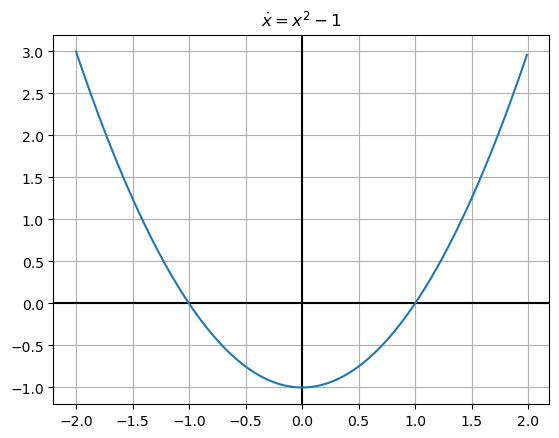

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(-2,2,0.01)
xdot = x**2 - 1
plt.title(r"$\dot{x} = x^2 - 1$")
plt.axvline(x=0, c="black")
plt.axhline(y=0, c="black")
plt.plot(x,xdot)
plt.grid()
plt.show()

Since this is a first order equation we have a nice physical way of thinking about it: at position $x$, a particles velocity is $x^2 -1$. So when the $x^2-1$ is positive, the particle's velocity is positive (or to the right) and vice versa. We can use this knowledge to work out qualitative behavor of our system. 

**&#9989; Do this** 

1. Consider a trajectory that starts at $x = -1.5$. Does this trajectory move to the right or left? 
2. What direction does a trajectory that starts at $x = 0$ go?
3. What direction does a trajectory that starts at $ x = 1.5$ go?
4. What trends do you notice? Do trajectories settle down at certain locations or blast off to infinity?

### Fixed Points

The **fixed points** of a system are where its derivative vanishes, that is $\dot{\mathbf{x}} = 0$. At any fixed point, a system is constant (why?). In the dynamical systems approach, we often care about charactarizing the behavor of systems near fixed points. In 1d, most fixed points are either stable (they attract trajectories) or unstable (they repel trajectories).

**&#9989; Do this** 

Find and characterize the fixed points of $\dot{x} = x^2-1$ as stable or unstable. 

Another way we can visualize these is with **slope fields**. Here we essentially plot the slopes $\dot{x}(x)$ over and over again for many values of $t$. The actual solution of the differential equation will be a curve that is always tangent to the local slope. Below we've plotted this using both `plt.quiver` and `plt.streamplot`

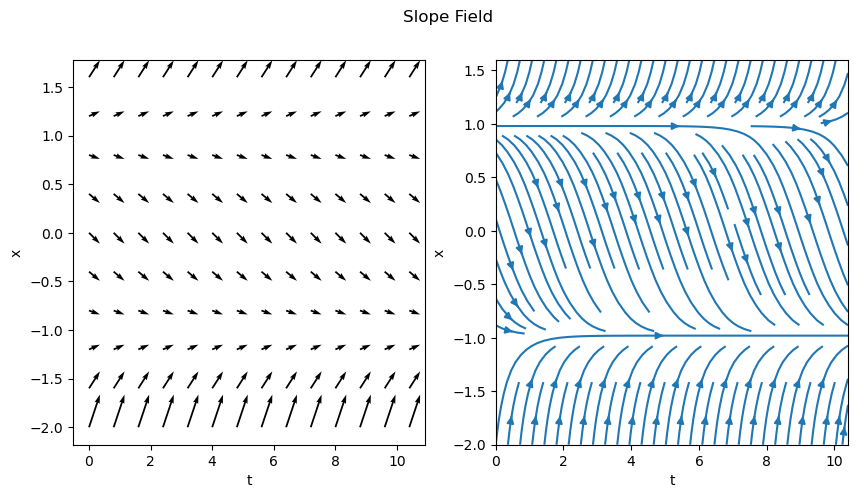

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(0, 11, 0.8)
x = np.arange(-2, 2, 0.4)

# Make grid
T, X = np.meshgrid(t, x)

# calculate derivative (dt is const so just use ones)
dx = X**2 - 1
dt = np.ones(dx.shape)

# plot
fig = plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.quiver(T,X,dt,dx)
plt.xlabel("t")
plt.ylabel("x")
plt.subplot(1,2,2)
plt.streamplot(T,X,dt,dx)
plt.xlabel("t")
plt.ylabel("x")
plt.suptitle("Slope Field")
plt.show()

## Reminders about the SHO

To get this started, let's remind ourselves of the phase portrait of the SHO. Recall that we separated the second order ODE into two first order ODEs, one for $x$ and one for $v_x$,

$$\dot{x} = v_x$$
$$\dot{v}_x=-\omega^2x$$

We then map out the phase space with the following conceptual interpretation:

- Phase space is a space in which all possible states of the system can be shown
    - a state is a collection of conditions of the state (it's known position and velocity in our case)
- Each state is a unique point in phase space
    - Think about ordered Cartesian pairs, there's a pair of numbers for every point in a 2D space
- Remember that knowing $x_0$ and $v_{x,0}$ means we can know $x(t)$ for all time (for that one trajectory/particular solution) given a linear ODE

We map the differential equation to the following conceptual interpretation: **How the state changes depends on location in phase space.** We can understand this as the time derivative for $x$ and $v_x$ change throughout the space.

For our 2D SHO case we are saying that how $x$ and $v_x$ change is proportional to the position in space:

$$\langle \dot{x}, \dot{v}_x \rangle = \langle v_x, -\omega^2 x\rangle$$

The process is:

1. Determine the location(s) of interest (i.e., $x$, $v_x$)
2. Compute the change in those quantities at the location (i.e., calculate $\dot{x}$ and $\dot{v}_x$ using our prescribed 1st order ODEs above)
3. At a given point ($x_0$, $v_{x,0}$), create an arrow the indicates the direction and magnitude of the changes to $x$ and $v_x$ at that location.
    - That arrow represents the local flow of the system at that point
4. Repeat for all points of interest
5. Plot arrows to demonstrate flow of the solutions in phase space

## Phase Portrait of the Simple Harmonic Oscillator

Below, we have written code that makes a phase portrait from the simple harmonic oscillator. It's written in terms of three functions that serve three purposes that you might want to modify in your own work:

* ``SHOPhasePortrait`` is a function that simply returns the relationship between the locations in phase space and how the phase variables change at that location. 
* ``ComputeSHOPhase`` is a function that uses that relationship and computes the values of the changes at every location. It returns two arrays, which contain all those values.
* ``SHOTrajectory`` is a function that takes a pair of points in space and computes the trajectory in phase space

By separating these ideas, we are illustrating the process for computing these phase portraits:
- Translate one  $Nth$ order differential equation to $N$ 1st order (Done earlier in this case)
- Put that into a code so you can compute the value of the changes at a location (``SHOPhasePotrait``)
- Call that computation a bunch to compute it at every location you want (``ComputeSHOPhase``)
- investigate specific trajectories in the space (``SHOTrajectory``)

We can then call these functions can plots the results.

In [3]:
def SHOPhasePortrait(x, vx, omega):
    '''SHOPhasePortrait returns the value of
    the change in the phase variables at a given location
    in phase space for the SHO model'''
    
    xdot, vxdot = [vx, -1*omega**2*x] ## Specific to this problem
    
    return xdot, vxdot

def ComputeSHOPhase(X, VX, omega):
    '''ComputeSHOPhase returns the changes in 
    the phase variables across a grid of locations
    that are specified'''
    
    ## Prep the arrays with zeros at the right size
    xdot, vxdot = np.zeros(X.shape), np.zeros(VX.shape)

    ## Set the limits of the loop based on how 
    ## many points in the arrays we have
    Xlim, Ylim = X.shape
    
    ## Calculate the changes at each location and add them to the arrays
    for i in range(Xlim):
        for j in range(Ylim):
            xloc = X[i, j]
            yloc = VX[i, j]
            xdot[i,j], vxdot[i,j] = SHOPhasePortrait(xloc, yloc, omega)
            
    return xdot, vxdot

def SHOTrajectory(x0, vx0, omega, N=100):
    '''SHOTrajectory computes the phase space
    trjectory using the analytical forms of the
    solution. Note this sloppy analytical approach
    only works because the SHO is perfectly sinusoidal.'''
    
    ## Only work with one period
    T = 2*np.pi/omega
    t = np.arange(0,T,T/N)
    
    ## I derived this in general with Acos(wt+phi)
    ## It's not in general a good approach
    ## because you are not guaranteed analytical 
    ## closed form trajectories in phase space
    
    phi = np.arctan2(-1*vx0, omega*x0) ## arctan(-vxo/(omega*x0)) taken correctly for the quadrant
    A = x0/np.cos(phi)
    x_traj = A*np.cos(omega*t+phi)
    v_traj = -omega*A*np.sin(omega*t+phi)
    
    return x_traj, v_traj

### Putting the functions to use

With these two functions, all we are left to do is specify the size of the space and the grid points (that is where exactly we are computing the changes). We use [meshgrid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) to make those arrays a set of Cartesian coordinates and then send that to our functions.

We then plot the results.

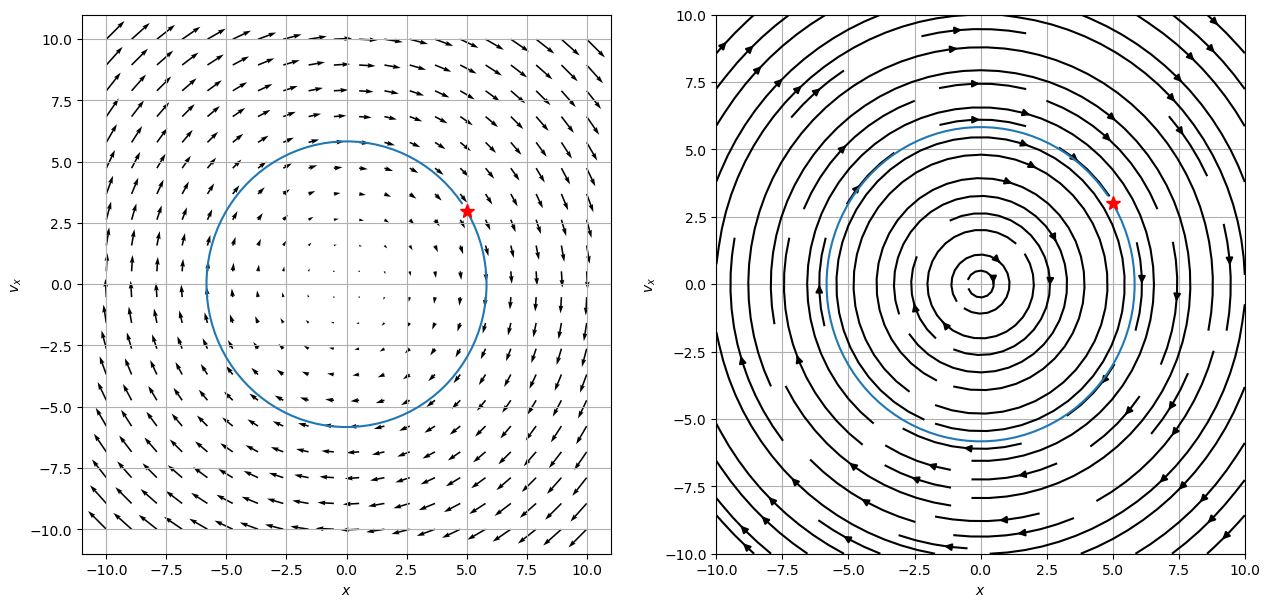

In [4]:
## Setting parameters and the phase space variables

omega = 1
x = np.linspace(-10.0, 10.0, 20)
vx = np.linspace(-10.0, 10.0, 20)

## Get back pairs of coordinates for every point in the space
X, VX = np.meshgrid(x, vx)

## Run our calculations
xdot, vxdot = ComputeSHOPhase(X, VX, omega)

x0 = 5
vx0 = 3
x_traj, v_traj = SHOTrajectory(x0, vx0, omega)

## Plot. plot. plot.
ax = plt.figure(figsize=(15,7))
plt.subplot(1,2,1)

## Plot with Quiver
Q = plt.quiver(X, VX, xdot, vxdot, color='k')

## Plot trajectory and the starting location
plt.plot(x_traj,v_traj)
plt.plot(x0, vx0, 'r*', markersize=10)

plt.xlabel('$x$')
plt.ylabel('$v_x$')
plt.grid()

plt.subplot(1,2,2)
## Plot with streamplot for subplot
Q = plt.streamplot(X, VX, xdot, vxdot, color='k')
plt.plot(x_traj,v_traj)
plt.plot(x0, vx0, 'r*', markersize=10)

plt.xlabel('$x$')
plt.ylabel('$v_x$')
plt.grid()

### What can phase space help us do? 

**&#9989; Do this** 

Let's remember a few things about the SHO. 

1. With your neighbors, list all the things you know about the SHO. Include anything we haven't discussed (e.g., the energetics of the problem).
2. Name which of those things you can see in the phase diagram. Which things are you sure you can see? What things don't seem to be able to be seen from the phase diagram? 
3. What do you remember about the energy of an SHO? Consider a harmonic oscillator in a known trajectory ($x(t) = A\cos(\omega t)$). Compute the total (conserved) energy of the oscillator as a function of time. 
    - Explain how your expression for energy conservation can be seen in your phase diagram. 
    - You might try to show analytically that the ellipse above is related to your energy conservation expression
4. What are the fixed points for this system? Can it be classified as stable/unstable or do we need to think of something new?

What do these plots tell you about all potential solutions?

## The Large Angle Pendulum

The Large Angle Pendulum is the first of a number of nonlinear differential equations out there. This one is quite special in that the integral that solves for the period of this pendulum has a name! It's called and [Elliptical Integral of the First Kind](https://en.wikipedia.org/wiki/Elliptic_integral). Elliptical because of the nature of the kernel of the integral, which has an elliptic form (in our case, one over the square root of a quantity squared subtracted from one, yes, seriously, we have a name for that).

Here's the pendulum in all it's glory.

![Large Angle Pendulum](../../assets/images/pendulum_bob.png)


The analytical solution for the period is given by:

$$T = 4\sqrt{\dfrac{L}{g}}\int_0^{\pi/2}\dfrac{d\theta}{\sqrt{1-k^2\sin^2(\theta)}}$$

To find the period, we have to use some form of computation, even it's the "well-known" [recurrence relationship](https://en.wikipedia.org/wiki/Elliptic_integral#Complete_elliptic_integral_of_the_first_kind) that was used for centuries to compute this integral **by hand**.

But let's try to gain insight from the phase space instead. We can [derive] the differential equation that describes the motion of the pendulum through an angle $\theta$ thusly:

$$\ddot{\theta} = -\dfrac{g}{L}\sin(\theta)$$

You have a second order differential equation for $\theta$. 

### Make a new phase portrait

**&#9989; Do this** 

With your partners,

1. Take the 2nd order ODE and make it two 1st order ODEs (one for $\theta$ and one for $\omega=\dot{\theta}$). Make sure you agree on the analytics.
2. Add those expressions to the function ```LAPPhasePortrait```
3. The rest of the code runs the same as before (we've engaged in reproducible and adaptable work!), so make some phase portraits. 
    - What do you notice? 
    - What physics is new? 
    - What physics is old? 
4. Play with parameters and build a story for what is going on with the motion.


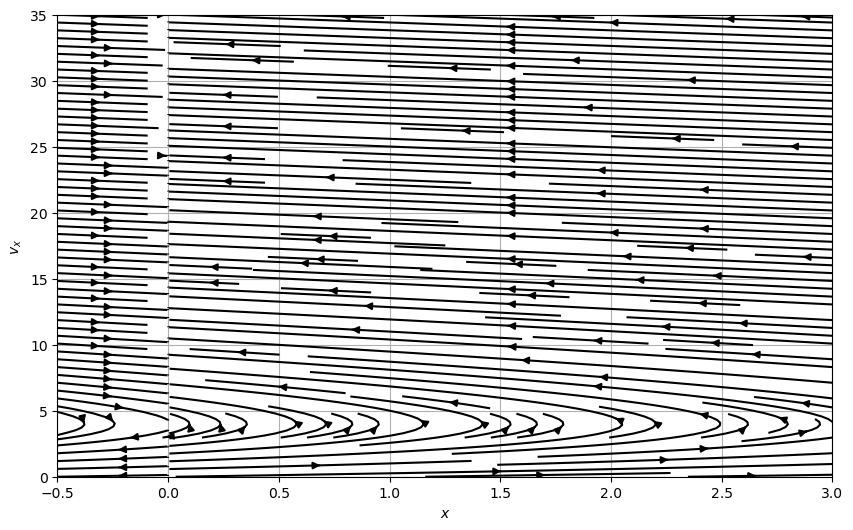

In [9]:
def LAPPhasePortrait(x, vx, omega0 = 10):
    
    #################
    ## CHANGE THIS ##
    #################
    xdot, vxdot = [0.4*x - 0.1*x*vx, 1/20*x*(2-1/10 * x + vx )] ## Specific to the problem
    
    return xdot, vxdot

def ComputeLAPPhase(X, VX, omega0):
    
    xdot, vxdot = np.zeros(X.shape), np.zeros(VX.shape)

    Xlim, Ylim = X.shape
    
    for i in range(Xlim):
        for j in range(Ylim):
            xloc = X[i, j]
            yloc = VX[i, j]
            xdot[i,j], vxdot[i,j] = LAPPhasePortrait(xloc, yloc, omega0)
            
    return xdot, vxdot

omega0 = 2
N = 40

x = np.linspace(-.5, 3.0, N)
vx = np.linspace(.0, 35.0, N)

X, VX = np.meshgrid(x, vx)

xdot, vxdot = ComputeLAPPhase(X, VX, omega0)

ax = plt.figure(figsize=(10,6))
Q = plt.streamplot(X, VX, xdot, vxdot, color='k',density=2)
plt.grid()

plt.xlabel('$x$')
plt.ylabel('$v_x$')
plt.show()

**&#9989; Do this** 

Find the fixed points of this system. Are they the same as in the SHO case? If they're different, what about this system makes it different?


## (Time Permitting) Fixed Points in 2 Dimensions

If we don't get to this in class today don't worry, we'll start out with this on thursday!

Now that we've stepped into two dimensional phase space, the amount of interesting geometry that our solutions can have is much greater. In particular, local behavior near fixed points can now exhibit much more complex behavior than just being stable or not, as we can see in this figure.

<img src="https://www.researchgate.net/publication/346614443/figure/fig11/AS:964859927728140@1607051941592/Classification-of-fixed-points-for-two-dimensional-nonlinear-systems-As-a-function-of.png" alt="Large Angle Pendulum" width="600"/>

So how do we definitively say what the behavior of our system is like near a fixed point? The anwer lies in **linearization**. A linear system in 2d is a system of the form:

$$
\dot{x} = ax + by \hspace{1in} \dot{y} = cx + dy
$$

Note we can convieniently write this in matrix notation:


$$
\dot{\mathbf{x}} = A\mathbf{x}
$$

Where 

$$
A = 
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\hspace{0.5in}\text{and} \hspace{0.5in} \mathbf{x} = \begin{bmatrix} x \\ y \end{bmatrix}
$$

These systems are understood quite well and play very nice mathematically (see strogatz chapter 5). Miraculously, the mathematical tools for classifying fixed points of linear systems carry over into nonlinear systems with little tweaking. This is because most nonlinear systems behave in linear ways near fixed points. This means we can **linearize** nonlinear systems. Here's how you do it:


Suppose you have a system given by:

$$
\dot{x} = f(x,y)
$$

$$
\dot{y} = g(x,y)
$$

With fixed point $(x^*,y^*)$. Near this fixed point, distrubances to the system will evolve approximatley according to:

$$
\begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix} = \begin{bmatrix} \frac{\partial f}{\partial x} & \frac{\partial f}{\partial y} \\ \frac{\partial g}{\partial x} & \frac{\partial g}{\partial y}\end{bmatrix} \begin{bmatrix}x - x^* \\ y - y^*\end{bmatrix}
$$

This is called the **linearized system**. The matrix

$$
A = \begin{bmatrix} \frac{\partial f}{\partial x} & \frac{\partial f}{\partial y} \\ \frac{\partial g}{\partial x} & \frac{\partial g}{\partial y}\end{bmatrix}_{(x^*,y^*)}
$$
is the **Jacobian matrix** at this fixed point, which is the multivariable version of the derivative. To categorize the fixed points of a given system at a fixed point, calculate $A$ for said fixed point, then find its Eigenvalues. Recall Eigenvalues are the $\lambda$ in $A\mathbf{v} = \lambda \mathbf{v}$. $2\times2$ matricies have (up to) 2 eigenvalues. These eigenvalues tell you about the stability of the system:

- $\mathrm{Re}(\lambda) > 0 $ for both eigenvalues: Repeller/Source (unstable)
- $\mathrm{Re}(\lambda) < 0 $ for both eigenvalues: Attractor/Sink  (stable)
- One eigenvalue positive, one negative: Saddle
- Both eigenvalues pure imaginary: Center

In fact one can learn quite a bit more from a these eigenvalues (see strogatz chapter 6 or section 5.4 [here](https://users.math.msu.edu/users/gnagy/teaching/ode.pdf)), but these charactarizations are a great starting point. 

**&#9989; Do this** 

Calculate the Jacobian matrix $A$ for a fixed point of the large angle pendulum.

<!-- and find its eigenvalues to charactarize the pendulum's behavior near this fixed point. Does this behavior match your intuition? Does this characterization change if you add drag to the model? -->